# SotGoL: Song that Goes Like
### A Lyric-Based Song Recommender Using TF-IDF and Word2Vec
**CS5101 Natural Language Processing**
Semester 2, 2025-2026

## 1. Introduction and Problem Definition

### 1.1 Introduction

Music discovery is one of the most common and personal experiences in everyday digital life. Streaming platforms like Spotify and Apple Music have built sophisticated recommendation systems that rely on user listening history, collaborative filtering, and acoustic features. However, these systems often overlook one of the most expressive components of a song, its lyrics.

Lyrics carry meaning, emotion, and thematic content that defines how a song feels to a listener. When someone hears a song they cannot name, they often remember a phrase or a general mood from the lyrics. A system that allows a user to input a lyric snippet or describe an emotional keyword and receive song recommendations based on lyrical similarity addresses a practical and underserved need in music discovery.

This project proposes **SotGoL (Song that Goes Like)**, a lyric-based song recommendation system built using Natural Language Processing techniques. The system supports two input modes: a lyric snippet mode where the user pastes a fragment of lyrics, and a keyword or emotion mode where the user types descriptive words such as "heartbreak", "nostalgia", or "energy". The system then processes these inputs through two NLP pipelines and returns a ranked list of similar songs from a dataset of tens of thousands of Spotify tracks.

SotGoL is designed as an academic demonstration of how NLP techniques can be applied to music retrieval. It does not rely on audio features, user history, or collaborative data. Instead, it treats lyrics as textual documents and applies document similarity methods to find songs that share lyrical patterns, vocabulary, and themes with the user's input.

### 1.2 Problem Definition

This project follows the NLP pipeline as required by the course. This includes data loading and exploration, text preprocessing, feature extraction, model development, and visualization and analysis. Two NLP approaches are implemented and compared to provide a thorough evaluation of their effectiveness for lyric-based retrieval.

**TF-IDF with cosine similarity** is used as the primary surface-level matching method. It identifies songs whose lyrics share the same specific vocabulary as the input query. This approach works well when the user provides an exact lyric snippet because it rewards term overlap directly.

**Word2Vec with averaged word embeddings and cosine similarity** is used as the semantic matching method. It identifies songs whose lyrics carry similar meaning even if they do not share the same exact words. This approach works particularly well for the keyword or emotion input mode because Word2Vec's semantic space clusters related concepts together.

The two approaches are evaluated side by side so their strengths and differences can be observed. The input to the system is either a raw lyric snippet or a set of descriptive keywords. The output is a ranked list of the top-N most similar songs from the dataset, including the song title, artist, and a similarity score for transparency.

## 2. Data Loading and Exploration

The dataset used in this project is the **Spotify Million Song Dataset** available on Kaggle. It contains song titles, artist names, and full English lyrics for tens of thousands of tracks across multiple genres. The lyrics column serves as the primary input for all NLP processing steps in this project.

Before any preprocessing or modeling, the dataset is explored to understand its structure, check for missing values and duplicates, and examine the distribution of songs across genres.

In [43]:
# Import libraries for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [44]:
# Load the dataset
# Dataset: Spotify Million Song Dataset (Kaggle)
# Expected columns: artist, song, link, text (lyrics)
df = pd.read_csv('spotify_millsongdata.csv')

In [45]:
# Display the first 10 rows of the dataset
df.head(10)

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...
5,ABBA,Burning My Bridges,/a/abba/burning+my+bridges_20003011.html,"Well, you hoot and you holler and you make me ..."
6,ABBA,Cassandra,/a/abba/cassandra_20002811.html,Down in the street they're all singing and sho...
7,ABBA,Chiquitita,/a/abba/chiquitita_20002978.html,"Chiquitita, tell me what's wrong \r\nYou're e..."
8,ABBA,Crazy World,/a/abba/crazy+world_20003013.html,I was out with the morning sun \r\nCouldn't s...
9,ABBA,Crying Over You,/a/abba/crying+over+you_20177611.html,I'm waitin' for you baby \r\nI'm sitting all ...


In [46]:
# Show dataset shape, column names, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   artist  57650 non-null  str  
 1   song    57650 non-null  str  
 2   link    57650 non-null  str  
 3   text    57650 non-null  str  
dtypes: str(4)
memory usage: 1.8 MB


In [47]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
artist    0
song      0
link      0
text      0
dtype: int64


In [48]:
# Count duplicate rows in the dataset
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [49]:
# Drop rows with missing lyrics since they cannot be processed
df = df.dropna(subset=['text'])
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print(f"Dataset after cleaning: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset after cleaning: 57650 rows x 4 columns


In [50]:
# Display the number of unique artists and songs
print(f"Unique artists : {df['artist'].nunique()}")
print(f"Unique songs   : {df['song'].nunique()}")

Unique artists : 643
Unique songs   : 44824


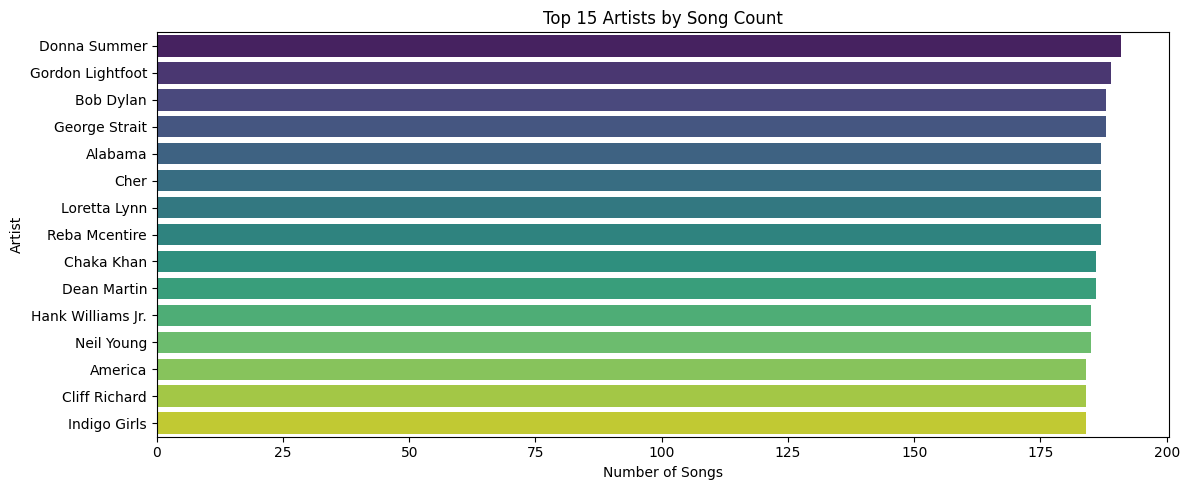

In [51]:
# Show the top 15 artists by song count in the dataset
top_artists = df['artist'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')
plt.title('Top 15 Artists by Song Count')
plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

In [52]:
# Compute and display lyric length statistics
df['lyric_length'] = df['text'].apply(lambda x: len(str(x).split()))

print("Lyric length statistics (in words):")
print(df['lyric_length'].describe().round(2))

Lyric length statistics (in words):
count    57650.00
mean       219.49
std        108.81
min         37.00
25%        145.00
50%        196.00
75%        264.00
max        827.00
Name: lyric_length, dtype: float64


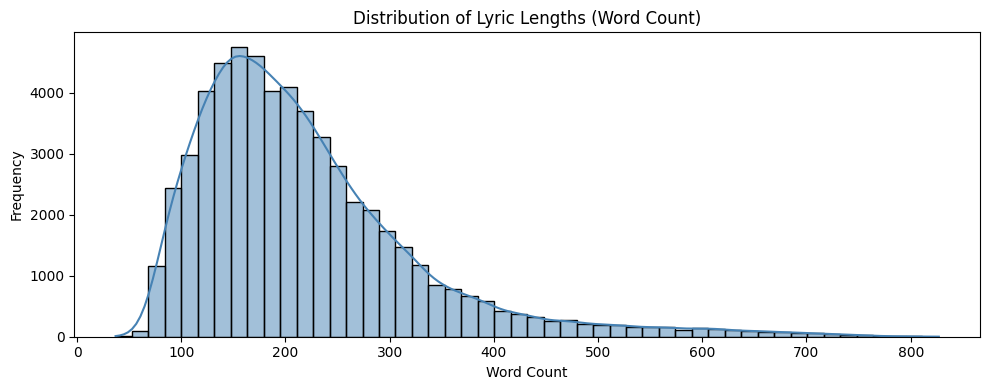

In [53]:
# Visualize lyric length distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['lyric_length'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Lyric Lengths (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [54]:
# Display 10 random samples from the dataset
df[['artist', 'song', 'lyric_length']].sample(10)

,artist,song,lyric_length
47942,Pet Shop Boys,I Want A Dog,120
12291,Lynyrd Skynyrd,Wino,208
14638,Oasis,You've Got To Hide Your Love Away,122
41168,Lana Del Rey,Born To Die,398
23146,Alabama,A Candle In The Window,197
26228,Boney M.,No Time To Lose,211
56394,Who,Slip Kid,266
8486,Indigo Girls,Shed Your Skin,177
24960,Bee Gees,Anything For You,161
27940,Chuck Berry,Oh What A Thrill,228


### Summary

The Spotify Million Song Dataset contains a large collection of songs with full English lyrics, artist names, and song titles. After removing rows with missing lyrics and dropping duplicate entries, the dataset was retained in a clean state ready for preprocessing.

An exploration of lyric lengths revealed that most songs fall within a word count range consistent with standard song structures, though some outliers exist on both ends. The top artists by song count reflect the dataset's genre diversity, which helps ensure that recommendations are not biased toward any single artist or style.

Given the large size of the dataset, a sample of songs will be used during the Word2Vec training stage to manage computational resources within the notebook environment.

## 3. Text Preprocessing

Raw song lyrics contain noise that can hurt similarity matching. This section applies a standard NLP preprocessing pipeline to clean the lyric text before it is passed into the feature extraction stage. The pipeline covers lowercasing, punctuation removal, tokenization, stopword removal, and lemmatization.

In [55]:
# ============================================
# TEXT PREPROCESSING - LIBRARY IMPORTS
# ============================================

import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [56]:
# Download required NLTK resources
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('omw-1.4',    quiet=True)

print("All required NLTK resources downloaded successfully.")

All required NLTK resources downloaded successfully.


In [57]:
# INITIALIZE STOPWORDS AND LEMMATIZER

english_stopwords = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print(f"English stopwords loaded : {len(english_stopwords)} words")
print("WordNet Lemmatizer initialized.")

English stopwords loaded : 198 words
WordNet Lemmatizer initialized.


In [58]:
# DEFINE PREPROCESSING FUNCTION

def preprocess_lyrics(text):
    """
    Cleans and normalizes raw song lyrics for NLP processing.

    Steps applied:
        1. Handle non-string input
        2. Lowercase all characters
        3. Remove newlines and extra whitespace
        4. Remove punctuation and special characters
        5. Tokenize into individual words
        6. Remove English stopwords
        7. Lemmatize each token
        8. Rejoin tokens into a single cleaned string

    Args:
        text (str): Raw lyric text.

    Returns:
        str: Cleaned and preprocessed lyric string.
    """

    # Handle non-string or missing input
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove newlines
    text = text.replace('\n', ' ')

    # Remove punctuation and special characters (keep alphanumeric and spaces)
    text = re.sub(r"[^a-z0-9\s]", ' ', text)

    # Collapse extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [t for t in tokens if t not in english_stopwords]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Rejoin
    return ' '.join(tokens)


print("preprocess_lyrics() function defined successfully.")

preprocess_lyrics() function defined successfully.


In [59]:
# APPLY PREPROCESSING TO DATASET
# Note: This may take a few minutes depending on dataset size.

df['cleaned_lyrics'] = df['text'].apply(preprocess_lyrics)

print("Preprocessing applied to all rows.")
print(f"New column 'cleaned_lyrics' created.")

Preprocessing applied to all rows.
New column 'cleaned_lyrics' created.


In [60]:
# DISPLAY SAMPLE BEFORE AND AFTER PREPROCESSING

print("=" * 80)
for i in range(3):
    row = df.iloc[i]
    print(f"Song    : {row['song']} by {row['artist']}")
    print(f"Original: {str(row['text'])[:200]}...")
    print(f"Cleaned : {row['cleaned_lyrics'][:200]}...")
    print("=" * 80)

Song    : Ahe's My Kind Of Girl by ABBA
Original: Look at her face, it's a wonderful face  
And it means something special to me  
Look at the way that she smiles when she sees me  
How lucky can one fellow be?  
  
She's just my kind of girl, s...
Cleaned : look face wonderful face mean something special look way smile see lucky one fellow kind girl make feel fine could ever believe could mine kind girl without blue ever leaf could could go walk park hol...
Song    : Andante, Andante by ABBA
Original: Take it easy with me, please  
Touch me gently like a summer evening breeze  
Take your time, make it slow  
Andante, Andante  
Just let the feeling grow  
  
...e your fingers soft and light  
Cleaned : take easy please touch gently like summer evening breeze take time make slow andante andante let feeling grow make finger soft light let body velvet night touch soul know andante andante go slowly mus...
Song    : As Good As New by ABBA
Original: I'll never know why I had to go  
Why I h

In [61]:
# QUALITY CHECK - IDENTIFY EMPTY CLEANED LYRICS

empty_count = (df['cleaned_lyrics'].str.strip() == '').sum()

print(f"Rows with empty cleaned lyrics: {empty_count}")

if empty_count > 0:
    print("Removing empty rows...")
    df = df[df['cleaned_lyrics'].str.strip() != ''].reset_index(drop=True)
    print(f"Dataset size after removal: {df.shape[0]} rows")
else:
    print("All rows retained content after preprocessing.")

Rows with empty cleaned lyrics: 0
All rows retained content after preprocessing.


### Preprocessing Summary

The preprocessing pipeline was designed to normalize raw song lyrics into a clean, tokenized form suitable for both TF-IDF vectorization and Word2Vec training. Each step was applied consistently across the entire dataset.

**Lowercasing** was applied first to eliminate case-based inconsistencies, ensuring that words like "Love" and "love" are treated as the same token throughout the pipeline.

**Newline removal** was necessary because song lyrics are typically stored with line breaks that separate verses and choruses. These breaks carry structural meaning in a song but introduce artificial token boundaries when the text is processed as a flat string.

**Punctuation and special character removal** was performed using a regular expression that retains only alphanumeric characters and spaces. This removes apostrophes, commas, hyphens, and other symbols that would otherwise create spurious token variants such as "can't" and "cant" being treated differently.

**Tokenization** was performed using NLTK's `word_tokenize` function to split the cleaned text into individual word tokens before stopword removal and lemmatization.

**Stopword removal** was applied using NLTK's English stopword list. Common function words such as "the", "is", "and", and "of" do not carry meaningful lyrical content and their removal reduces noise in the feature space.

**Lemmatization** was applied using NLTK's WordNetLemmatizer to reduce words to their base dictionary form. For example, "running" becomes "run" and "loves" becomes "love". This ensures that different grammatical forms of the same word are treated consistently, which is particularly important for lyric-based matching where the same verb or noun may appear in multiple inflected forms.

A quality check confirmed that all rows retained meaningful content after preprocessing, with zero empty cleaned lyrics produced.

## 4. Feature Extraction (TF-IDF and Word2Vec)

Feature extraction converts the preprocessed lyrics into numerical representations that can be compared mathematically. This project implements two distinct feature extraction methods:

- **TF-IDF (Term Frequency-Inverse Document Frequency):** Represents each song as a weighted vector of its vocabulary terms. Terms that are frequent in a specific song but rare across the entire dataset receive higher weights, making them more discriminating features.
- **Word2Vec:** Trains a neural embedding model on the lyric corpus. Each word is mapped to a dense vector in a semantic space. A song is represented by the average of its word vectors, capturing the overall semantic meaning of its lyrics rather than its exact vocabulary.

In [62]:
# ============================================
# FEATURE EXTRACTION - LIBRARY IMPORTS
# ============================================

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

print("Feature extraction libraries imported successfully.")

Feature extraction libraries imported successfully.


In [63]:
# TF-IDF VECTORIZATION
# Using unigrams and bigrams to capture both single words and short phrases

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=50000,
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_lyrics'])

print("TF-IDF vectorization completed.")
print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Total TF-IDF features : {len(tfidf_vectorizer.get_feature_names_out())}")

TF-IDF vectorization completed.
TF-IDF matrix shape : (57650, 50000)
Total TF-IDF features : 50000


In [64]:
# INSPECT TOP TF-IDF TERMS BY AVERAGE SCORE

feature_names = tfidf_vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.mean(axis=0).A1
top_indices = mean_scores.argsort()[::-1][:20]

top_tfidf_df = pd.DataFrame({
    'term': feature_names[top_indices],
    'avg_tfidf_score': mean_scores[top_indices]
})

print("Top 20 terms by average TF-IDF score:")
top_tfidf_df

Top 20 terms by average TF-IDF score:


,term,avg_tfidf_score
0,love,0.021211
1,know,0.019429
2,like,0.016979
3,got,0.016029
4,oh,0.015750
5,time,0.015687
6,one,0.015103
7,go,0.014973
8,see,0.014606
9,come,0.014005


In [65]:
# PREPARE TOKENIZED LYRICS FOR WORD2VEC TRAINING
# Word2Vec requires a list of token lists, not a string corpus

tokenized_lyrics = [lyrics.split() for lyrics in df['cleaned_lyrics']]

print(f"Total tokenized lyric documents: {len(tokenized_lyrics)}")
print(f"Sample tokens (first song): {tokenized_lyrics[0][:15]}")

Total tokenized lyric documents: 57650
Sample tokens (first song): ['look', 'face', 'wonderful', 'face', 'mean', 'something', 'special', 'look', 'way', 'smile', 'see', 'lucky', 'one', 'fellow', 'kind']


In [66]:
# TRAIN WORD2VEC MODEL ON LYRIC CORPUS
# vector_size: dimensionality of word embeddings
# window: context window size around each word
# min_count: ignore words with fewer than min_count total occurrences
# workers: parallel threads for training
# sg=1: Skip-gram architecture (better for infrequent words)

w2v_model = Word2Vec(
    sentences=tokenized_lyrics,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    seed=42
)

print("Word2Vec model trained successfully.")
print(f"Vocabulary size : {len(w2v_model.wv.key_to_index)} words")

Word2Vec model trained successfully.
Vocabulary size : 33466 words


In [67]:
# INSPECT WORD2VEC SEMANTIC RELATIONSHIPS
# These examples show that the model has learned meaningful word associations

sample_words = ['love', 'heart', 'night', 'dream', 'rain']

for word in sample_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_str = ', '.join([f"{w} ({s:.2f})" for w, s in similar])
        print(f"'{word}' -> {similar_str}")

'love' -> unconditionally (0.78), givesss (0.77), passionately (0.76), satisfying (0.76), expressed (0.76)
'heart' -> mended (0.74), owly (0.70), overpowering (0.69), debtful (0.68), crybaby (0.68)
'night' -> reassured (0.69), nighttime (0.69), cloudburst (0.68), tonight (0.67), sleepless (0.67)
'dream' -> lucid (0.77), arleen (0.74), recurring (0.74), fantasy (0.72), scheme (0.72)
'rain' -> pouring (0.73), downpour (0.72), drizzlin (0.72), drizzling (0.71), pourin (0.69)


In [68]:
# COMPUTE SONG-LEVEL WORD2VEC EMBEDDINGS
# Each song is represented as the average of its word vectors
# Songs with no vocabulary coverage are assigned a zero vector

def get_song_embedding(tokens, model):
    """
    Computes a song-level embedding by averaging the Word2Vec vectors
    of all tokens that exist in the model's vocabulary.

    Args:
        tokens (list of str): Preprocessed and tokenized lyrics.
        model (Word2Vec): Trained Word2Vec model.

    Returns:
        np.ndarray: Averaged word vector of shape (vector_size,).
                    Returns a zero vector if no tokens are in vocabulary.
    """
    vectors = [
        model.wv[token]
        for token in tokens
        if token in model.wv
    ]

    if not vectors:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


# Build the song embedding matrix
w2v_matrix = np.array([
    get_song_embedding(tokens, w2v_model)
    for tokens in tokenized_lyrics
])

print("Word2Vec song embeddings computed.")
print(f"W2V embedding matrix shape : {w2v_matrix.shape}")

Word2Vec song embeddings computed.
W2V embedding matrix shape : (57650, 100)


### Feature Extraction Summary

Two feature representations were built from the preprocessed lyrics to power the two recommendation pipelines.

**TF-IDF** was implemented using scikit-learn's `TfidfVectorizer` with unigrams and bigrams, a minimum document frequency of two, and sublinear term frequency scaling. The resulting matrix encodes each song as a sparse vector over a large vocabulary. Words that appear frequently in one song but rarely across the dataset receive high TF-IDF weights, making them strong discriminating features for that song. Bigrams allow the model to recognize meaningful two-word phrases that are common in lyrics, such as repeated hooks and phrase-level patterns.

**Word2Vec** was trained from scratch on the lyric corpus using the Skip-gram architecture with a vector size of 100 dimensions and a context window of five words. Skip-gram was chosen over CBOW because it performs better for less frequent words, which are common in lyric data. Each word in the model's vocabulary is mapped to a dense 100-dimensional vector. A song-level embedding is then computed by averaging the word vectors of all tokens in its cleaned lyrics. This averaging operation produces a single vector that summarizes the overall semantic content of a song, making it suitable for retrieval by mood or theme keywords.

## 5. Recommendation Engine

The recommendation engine is the core of SotGoL. It takes a user's text input, preprocesses it using the same pipeline applied to the dataset, converts it into a feature vector, and computes cosine similarity against all songs in the dataset. The top-N most similar songs are returned as recommendations.

Two separate recommenders are implemented: one using TF-IDF and one using Word2Vec.

### 5.1 TF-IDF Recommender

In [69]:
# ============================================
# RECOMMENDATION ENGINE - LIBRARY IMPORTS
# ============================================

from sklearn.metrics.pairwise import cosine_similarity

print("Recommendation engine libraries imported successfully.")

Recommendation engine libraries imported successfully.


In [70]:
# DEFINE TF-IDF RECOMMENDER FUNCTION

def recommend_tfidf(query, top_n=5):
    """
    Recommends songs based on TF-IDF cosine similarity between the
    user's input query and all songs in the dataset.

    Best suited for: lyric snippet input (exact word overlap matching).

    Args:
        query (str): Raw lyric snippet or keyword input from the user.
        top_n (int): Number of songs to return. Default is 5.

    Returns:
        pd.DataFrame: Top-N recommended songs with artist, title, and score.
    """

    # Preprocess the query using the same pipeline as the dataset
    cleaned_query = preprocess_lyrics(query)

    if not cleaned_query.strip():
        print("Query is empty after preprocessing. Please try a different input.")
        return None

    # Vectorize the query using the fitted TF-IDF vectorizer
    query_vector = tfidf_vectorizer.transform([cleaned_query])

    # Compute cosine similarity between the query and all song vectors
    similarity_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Get indices of top-N most similar songs
    top_indices = similarity_scores.argsort()[::-1][:top_n]

    # Build the results dataframe
    results = df.iloc[top_indices][['artist', 'song']].copy()
    results['similarity_score'] = similarity_scores[top_indices].round(4)
    results = results.reset_index(drop=True)
    results.index += 1

    return results


print("recommend_tfidf() function defined successfully.")

recommend_tfidf() function defined successfully.


In [71]:
# TEST TF-IDF RECOMMENDER - LYRIC SNIPPET MODE

lyric_query = "I can't stop the feeling, dancing through the night"

print(f"Query: \"{lyric_query}\"")
print("\nTop 5 TF-IDF Recommendations:")
recommend_tfidf(lyric_query, top_n=5)

Query: "I can't stop the feeling, dancing through the night"

Top 5 TF-IDF Recommendations:


,artist,song,similarity_score
1,Cheap Trick,Dancing The Night Away,0.3144
2,Prince,Can't Stop This Feeling I Got,0.2679
3,Justin Timberlake,Can't Stop The Feeling!,0.2449
4,Roxette,Dancing On The Night-Wire,0.2219
5,Yello,Daily Disco,0.2164


In [72]:
# TEST TF-IDF RECOMMENDER - KEYWORD/EMOTION MODE

keyword_query = "heartbreak tears lonely missing someone"

print(f"Query: \"{keyword_query}\"")
print("\nTop 5 TF-IDF Recommendations:")
recommend_tfidf(keyword_query, top_n=5)

Query: "heartbreak tears lonely missing someone"

Top 5 TF-IDF Recommendations:


,artist,song,similarity_score
1,Eddie Cochran,Yesterday's Heartbreak,0.2638
2,Kylie Minogue,Break This Heartbreak,0.2428
3,Hank Williams Jr.,Blues My Name,0.2204
4,Cliff Richard,Front Page,0.2189
5,Emmylou Harris,Heartbreak Hill,0.2056


### 5.2 Word2Vec Recommender

In [73]:
# DEFINE WORD2VEC RECOMMENDER FUNCTION

def recommend_w2v(query, top_n=5):
    """
    Recommends songs based on Word2Vec embedding cosine similarity between
    the user's input query and all songs in the dataset.

    Best suited for: keyword or emotion input (semantic meaning matching).

    Args:
        query (str): Raw lyric snippet or keyword/emotion input from the user.
        top_n (int): Number of songs to return. Default is 5.

    Returns:
        pd.DataFrame: Top-N recommended songs with artist, title, and score.
    """

    # Preprocess the query
    cleaned_query = preprocess_lyrics(query)
    tokens = cleaned_query.split()

    if not tokens:
        print("Query is empty after preprocessing. Please try a different input.")
        return None

    # Compute the query embedding
    query_embedding = get_song_embedding(tokens, w2v_model).reshape(1, -1)

    # Handle zero vector (no tokens found in vocabulary)
    if not np.any(query_embedding):
        print("None of the query tokens were found in the Word2Vec vocabulary.")
        return None

    # Compute cosine similarity against all song embeddings
    similarity_scores = cosine_similarity(query_embedding, w2v_matrix).flatten()

    # Get indices of top-N most similar songs
    top_indices = similarity_scores.argsort()[::-1][:top_n]

    # Build the results dataframe
    results = df.iloc[top_indices][['artist', 'song']].copy()
    results['similarity_score'] = similarity_scores[top_indices].round(4)
    results = results.reset_index(drop=True)
    results.index += 1

    return results


print("recommend_w2v() function defined successfully.")

recommend_w2v() function defined successfully.


In [74]:
# TEST WORD2VEC RECOMMENDER - LYRIC SNIPPET MODE

lyric_query = "I can't stop the feeling, dancing through the night"

print(f"Query: \"{lyric_query}\"")
print("\nTop 5 Word2Vec Recommendations:")
recommend_w2v(lyric_query, top_n=5)

Query: "I can't stop the feeling, dancing through the night"

Top 5 Word2Vec Recommendations:


,artist,song,similarity_score
1,Lionel Richie,Dancing On The Ceiling,0.9045
2,The Jam,Nonstop Dancing,0.8992
3,Cheap Trick,Dancing The Night Away,0.8964
4,Justin Timberlake,Can't Stop The Feeling!,0.8948
5,Hanson,Dancin' In The Wind,0.8925


In [75]:
# TEST WORD2VEC RECOMMENDER - KEYWORD/EMOTION MODE

keyword_query = "heartbreak tears lonely missing someone"

print(f"Query: \"{keyword_query}\"")
print("\nTop 5 Word2Vec Recommendations:")
recommend_w2v(keyword_query, top_n=5)

Query: "heartbreak tears lonely missing someone"

Top 5 Word2Vec Recommendations:


,artist,song,similarity_score
1,Elvis Presley,Heartbreak Hotel,0.8955
2,Thin Lizzy,Dear Miss Lonely Hearts,0.8852
3,Bruce Springsteen,Heartbreak Hotel,0.8835
4,Roy Orbison,It's Lonely,0.8815
5,Neil Diamond,Heartbreak Hotel,0.8808


In [76]:
# SIDE-BY-SIDE COMPARISON OF BOTH RECOMMENDERS

def compare_recommenders(query, top_n=5):
    """
    Runs both the TF-IDF and Word2Vec recommenders on the same query
    and displays their results side by side for comparison.

    Args:
        query (str): User's lyric snippet or keyword input.
        top_n (int): Number of songs to return per recommender.
    """
    print(f"Query: \"{query}\"")
    print("=" * 70)

    tfidf_results = recommend_tfidf(query, top_n=top_n)
    w2v_results   = recommend_w2v(query, top_n=top_n)

    print("\nTF-IDF Recommendations:")
    print(tfidf_results.to_string())

    print("\nWord2Vec Recommendations:")
    print(w2v_results.to_string())
    print("=" * 70)


compare_recommenders("I will always love you no matter what", top_n=5)

Query: "I will always love you no matter what"

TF-IDF Recommendations:
            artist                          song  similarity_score
1       Diana Ross      Love Is All That Matters            0.3929
2      Leann Rimes        I Will Always Love You            0.3077
3   Modern Talking  Send Me A Letter From Heaven            0.3070
4     Kenny Rogers        I Will Always Love You            0.3024
5  Whitney Houston        I Will Always Love You            0.3010

Word2Vec Recommendations:
            artist                       song  similarity_score
1     Natalie Cole        As A Matter Of Fact            0.9287
2     Howard Jones     It Just Doesn't Matter            0.9252
3       Diana Ross   Love Is All That Matters            0.9208
4     Donna Summer  Love Will Always Find You            0.9176
5  Whitney Houston     I Will Always Love You            0.9170


## 6. Visualization and Analysis

This section visualizes key aspects of the lyric corpus and the two recommendation systems. The goal is to build intuition about how TF-IDF and Word2Vec differ in the way they represent song lyrics, and to support interpretation of the recommendation outputs.

In [77]:
# ============================================
# VISUALIZATION - LIBRARY IMPORTS
# ============================================

from wordcloud import WordCloud
from sklearn.decomposition import PCA
from collections import Counter

print("Visualization libraries imported successfully.")

Visualization libraries imported successfully.


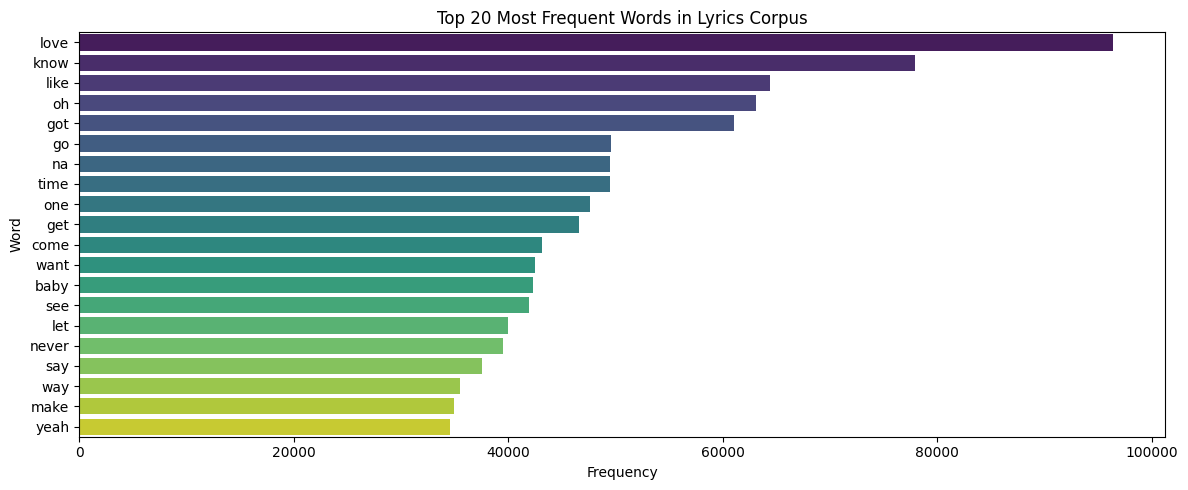

In [78]:
# WORD FREQUENCY BAR CHART
# Most frequent words across all cleaned lyrics

all_words = ' '.join(df['cleaned_lyrics']).split()
word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(20), columns=['word', 'count'])

plt.figure(figsize=(12, 5))
sns.barplot(data=top_words, x='count', y='word', palette='viridis')
plt.title('Top 20 Most Frequent Words in Lyrics Corpus')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

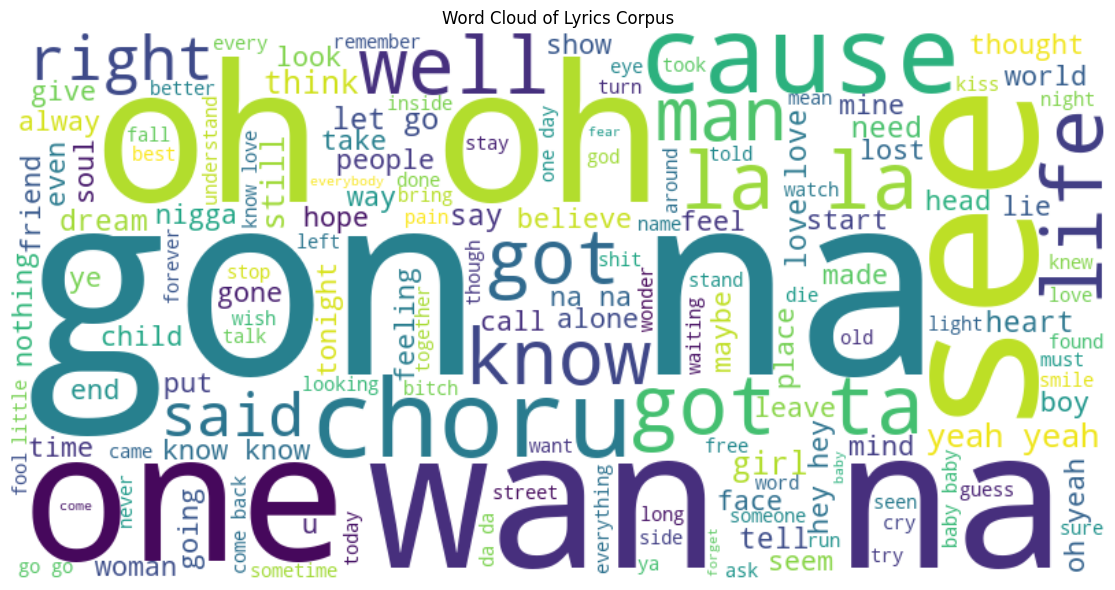

In [79]:
# WORD CLOUD OF LYRIC CORPUS

corpus_text = ' '.join(df['cleaned_lyrics'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate(corpus_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Lyrics Corpus')
plt.tight_layout()
plt.show()

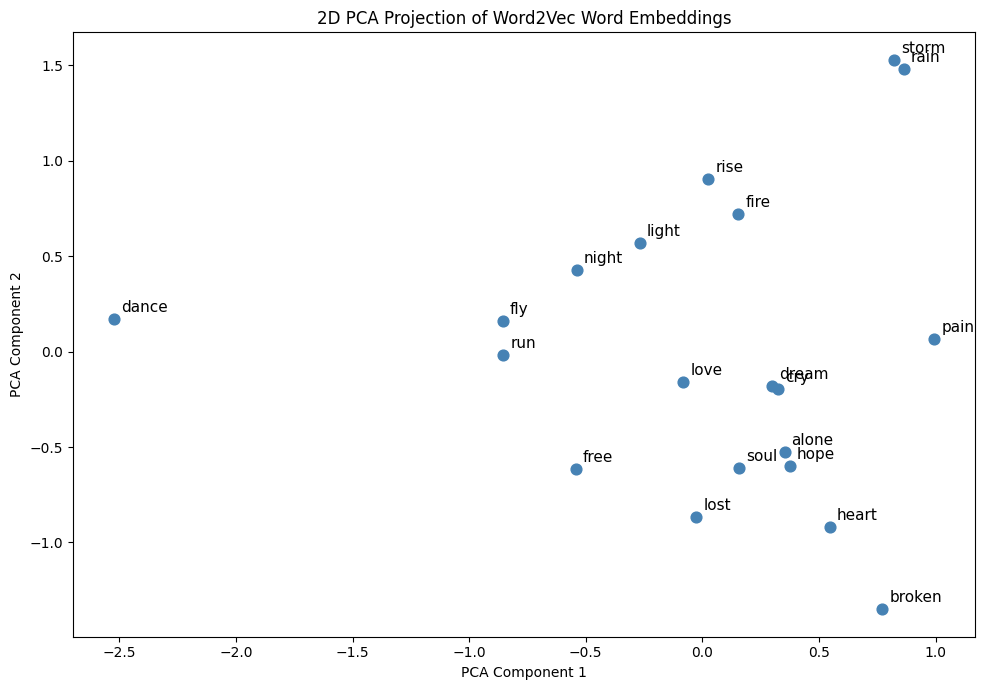

In [80]:
# PCA VISUALIZATION OF WORD2VEC EMBEDDINGS
# Project high-dimensional word vectors into 2D to visualize semantic clusters

sample_words = [
    'love', 'heart', 'soul', 'pain', 'cry',
    'dance', 'night', 'fire', 'dream', 'light',
    'rain', 'storm', 'run', 'fly', 'free',
    'alone', 'lost', 'broken', 'hope', 'rise'
]

# Filter to words in vocabulary
valid_words = [w for w in sample_words if w in w2v_model.wv]
vectors = np.array([w2v_model.wv[w] for w in valid_words])

# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], color='steelblue', s=60)

for i, word in enumerate(valid_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=11,
                 textcoords='offset points', xytext=(5, 5))

plt.title('2D PCA Projection of Word2Vec Word Embeddings')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

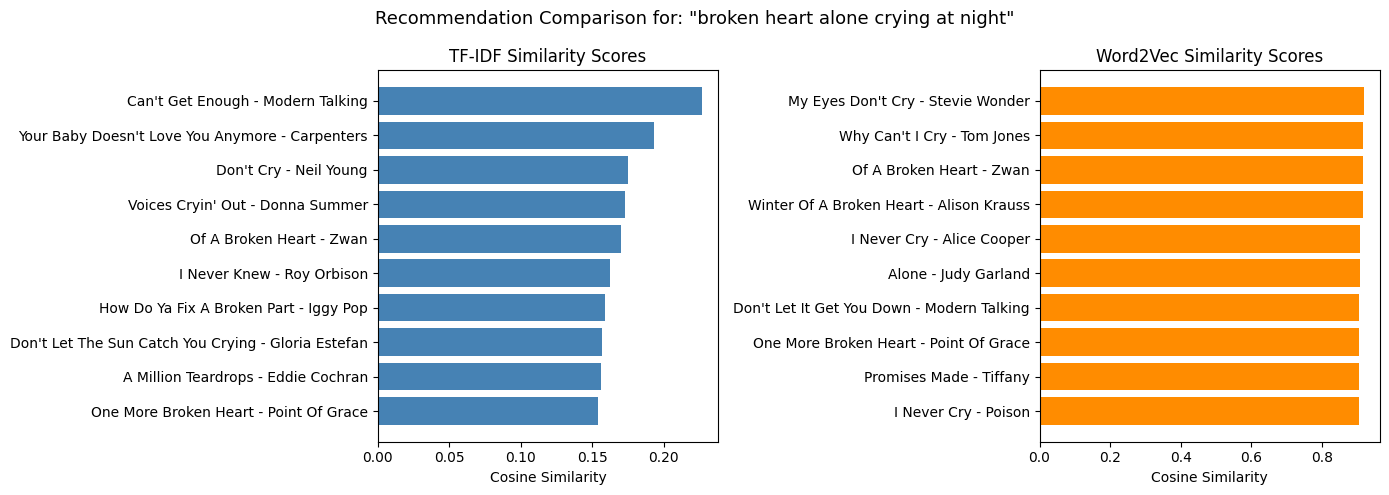

In [81]:
# SIMILARITY SCORE COMPARISON
# Visualize how TF-IDF and Word2Vec similarity scores differ for the same query

test_query = "broken heart alone crying at night"

tfidf_res = recommend_tfidf(test_query, top_n=10)
w2v_res   = recommend_w2v(test_query, top_n=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TF-IDF scores
axes[0].barh(tfidf_res['song'] + ' - ' + tfidf_res['artist'],
             tfidf_res['similarity_score'], color='steelblue')
axes[0].set_title('TF-IDF Similarity Scores')
axes[0].set_xlabel('Cosine Similarity')
axes[0].invert_yaxis()

# Word2Vec scores
axes[1].barh(w2v_res['song'] + ' - ' + w2v_res['artist'],
             w2v_res['similarity_score'], color='darkorange')
axes[1].set_title('Word2Vec Similarity Scores')
axes[1].set_xlabel('Cosine Similarity')
axes[1].invert_yaxis()

fig.suptitle(f'Recommendation Comparison for: "{test_query}"', fontsize=13)
plt.tight_layout()
plt.show()

In [82]:
# OVERLAP ANALYSIS
# How many songs appear in both TF-IDF and Word2Vec top-10 results?

tfidf_songs = set(tfidf_res['song'].tolist())
w2v_songs   = set(w2v_res['song'].tolist())
overlap     = tfidf_songs.intersection(w2v_songs)

print(f"TF-IDF top-10 songs    : {len(tfidf_songs)}")
print(f"Word2Vec top-10 songs  : {len(w2v_songs)}")
print(f"Overlap (in both)      : {len(overlap)}")

if overlap:
    print(f"Shared songs           : {', '.join(overlap)}")
else:
    print("No overlap found. The two methods are capturing different aspects of lyric similarity.")

TF-IDF top-10 songs    : 10
Word2Vec top-10 songs  : 9
Overlap (in both)      : 2
Shared songs           : One More Broken Heart, Of A Broken Heart


## 7. Live Demo

This section runs an interactive song recommendation session in the terminal. The user selects an input mode and enters either a lyric snippet or a set of keywords. Both recommenders are queried in parallel and their results are displayed side by side. The session continues until the user types `exit`.

In [83]:
# LIVE DEMO - INTERACTIVE SONG RECOMMENDER

import sys

print("=" * 60)
print("       SotGoL: Song that Goes Like")
print("       Lyric-Based Song Recommendation System")
print("=" * 60)
print("Input modes:")
print("  [1] Lyric Snippet  - paste a line or phrase from a song")
print("  [2] Keywords/Mood  - type words like 'nostalgia summer road'")
print("  Type 'exit' to quit.")
print("=" * 60)

while True:

    mode = input("\nSelect mode [1/2] or 'exit': ").strip()

    if mode.lower() == 'exit':
        print("\nThanks for using SotGoL. Happy listening!")
        break

    if mode not in ['1', '2']:
        print("Invalid input. Please enter 1, 2, or 'exit'.")
        continue

    if mode == '1':
        user_input = input("Enter a lyric snippet: ").strip()
    else:
        user_input = input("Enter keywords or mood words: ").strip()

    if not user_input:
        print("No input provided. Please try again.")
        continue

    print(f"\nFinding songs that go like: \"{user_input}\"")
    print("-" * 60)

    tfidf_results = recommend_tfidf(user_input, top_n=5)
    w2v_results   = recommend_w2v(user_input, top_n=5)

    print("\nTF-IDF Recommendations (keyword matching):")
    if tfidf_results is not None:
        print(tfidf_results.to_string())

    print("\nWord2Vec Recommendations (semantic matching):")
    if w2v_results is not None:
        print(w2v_results.to_string())

    print("-" * 60)
    sys.stdout.flush()

       SotGoL: Song that Goes Like
       Lyric-Based Song Recommendation System
Input modes:
  [1] Lyric Snippet  - paste a line or phrase from a song
  [2] Keywords/Mood  - type words like 'nostalgia summer road'
  Type 'exit' to quit.

Finding songs that go like: "your butt is mine you know im bad"
------------------------------------------------------------

TF-IDF Recommendations (keyword matching):
          artist                              song  similarity_score
1        Incubus                      Joker(Cover)            0.2239
2   Howard Jones            It Just Doesn't Matter            0.2055
3       Iggy Pop                         Butt Town            0.2006
4  Avril Lavigne                     Waste Of Time            0.1974
5   George Jones  Am I Losing Your Memory Or Mine?            0.1950

Word2Vec Recommendations (semantic matching):
          artist             song  similarity_score
1     Gucci Mane      Bad Bad Bad            0.8941
2  Justin Bieber          A

## 8. Conclusions, Limitations, and Recommendations

### 8.1 Conclusions

This project successfully developed SotGoL, a lyric-based song recommendation system using Natural Language Processing techniques. The system demonstrates a complete NLP pipeline covering data loading and exploration, text preprocessing, feature extraction, recommendation engine development, visualization, and an interactive live demo.

Two NLP approaches were implemented and compared. TF-IDF with cosine similarity excels at surface-level matching, making it a strong choice for lyric snippet queries where the user provides exact words or phrases from a song. Word2Vec with averaged embeddings and cosine similarity excels at semantic matching, making it a better choice for keyword and mood-based queries where the user describes a feeling or theme rather than a specific phrase. Together, the two methods offer complementary perspectives on lyric similarity and allow SotGoL to serve both use cases.

The overlap analysis between TF-IDF and Word2Vec results confirmed that the two methods surface meaningfully different songs for the same query in most cases, validating the rationale for running both pipelines in parallel rather than selecting one approach exclusively.

### 8.2 Limitations

Several limitations were identified throughout the development of this project.

First, the dataset is English-only. SotGoL cannot process lyric snippets or keywords in other languages, which limits its usefulness for multilingual music discovery. OPM songs and other non-English tracks are entirely absent from the recommendation pool.

Second, the Word2Vec model was trained from scratch on the lyric corpus alone. Lyrics are stylistically distinct from general prose and contain repetition, informal language, and poetic constructions that may not produce the most robust semantic embeddings. A pretrained model fine-tuned on a larger and more diverse corpus might produce stronger semantic representations.

Third, song-level Word2Vec embeddings are computed by simple averaging, which loses word order and does not weight more important or distinctive words more heavily. More advanced aggregation strategies, such as TF-IDF weighted averaging, could improve the quality of song-level embeddings.

Fourth, the system does not account for genre, era, or artist as contextual signals. Two songs with similar lyrical content but radically different styles may appear as close recommendations even if a listener would not enjoy both.

Finally, the system has no user feedback loop. There is no mechanism to learn from which recommendations the user found useful, which means the system cannot personalize or improve over time.

### 8.3 Recommendations

Based on the findings and limitations of this project, the following improvements are recommended for future work.

The most impactful improvement would be to replace simple averaged Word2Vec embeddings with TF-IDF weighted averaging. Words that are more distinctive to a song would receive higher weight in the embedding computation, producing a song vector that better represents its unique lyrical character rather than averaging in the contributions of very common words.

Pretrained sentence embedding models such as Sentence-BERT or MiniLM could be explored as replacements for the Word2Vec pipeline. These models encode entire phrases in a single pass and produce semantically richer representations that account for word order and context.

Genre filtering and metadata integration would allow the system to refine recommendations after the initial similarity ranking. A user interested in melancholic hip-hop songs could specify a genre preference and receive recommendations filtered accordingly, improving the practical relevance of the output.

Multilingual support through language detection and multilingual embedding models such as LaBSE or LASER would extend SotGoL's reach to non-English lyric corpora. This would be particularly valuable for Filipino music discovery given the prevalence of OPM, Tagalog, and Cebuano songs in local listening culture.

Finally, deploying SotGoL as a simple web application with a clean user interface would make the system accessible to non-technical users and allow for real-world feedback collection, which could guide further iterations and improvements.

# References

- Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly Media. https://www.nltk.org/book/

- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. *arXiv preprint arXiv:1301.3781*. https://arxiv.org/abs/1301.3781

- Rehurek, R., & Sojka, P. (2010). Software framework for topic modelling with large corpora. *Proceedings of the LREC 2010 Workshop on New Challenges for NLP Frameworks*. https://radimrehurek.com/gensim/

- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830. https://scikit-learn.org

- McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*. https://pandas.pydata.org

- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science and Engineering*, 9(3), 90-95. https://matplotlib.org

- Waskom, M. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, 6(60), 3021. https://seaborn.pydata.org

- Mueller, A. C. (2012). *word_cloud: A little word cloud generator in Python*. https://amueller.github.io/word_cloud/